# Soft kNN Explanations versus SHAP  
## Jupyter notebook companion to the tutorial paper

This notebook accompanies the paper:

**Soft Nearest-Neighbor Explanations versus SHAP: A Tutorial on What Feature Attribution Misses in Local Empirical-Measure Models**

The paper’s central distinction is:

\[
\text{SHAP explains } x_0 \mapsto \hat y(x_0),
\qquad
\text{soft kNN explains } x_0 \mapsto w(x_0) \mapsto \hat y(x_0).
\]

This notebook implements the paper’s examples using an explicit soft kNN model where the true local mechanism is visible.

We compare:

1. **Outer feature attribution**: SHAP-style values for the function \(x_0 \mapsto \hat y(x_0)\)
2. **Inner neighborhood explanation**: the weights \(w_i(x_0)\), local label dispersion, effective neighbor count and feature distance decomposition
3. **Visualization panels**: top neighbors, distance-label plots and SHAP versus soft-kNN feature scores

The goal is not to benchmark SHAP. The goal is to show, using a transparent model, that feature attribution and local empirical-measure explanation answer different questions.

## 0. Setup

This notebook uses only `numpy`, `pandas` and `matplotlib`.  

It implements a small exact SHAP-style explainer for low-dimensional examples, so the tutorial does not depend on the external `shap` package.

For \(p \leq 3\), we compute exact interventional Shapley values by enumerating feature coalitions and integrating missing features over a background sample.

In [1]:
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

def standardize_train(X):
    # Return standardized X plus mean and std.
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return (X - mu) / sd, mu, sd

def standardize_apply(X, mu, sd):
    return (X - mu) / sd

def soft_knn_predict(X_train, y_train, X_query, tau=0.3, lambdas=None, return_details=False):
    # Explicit soft kNN using weighted squared Euclidean distance.
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    X_query = np.asarray(X_query, dtype=float)
    if X_query.ndim == 1:
        X_query = X_query.reshape(1, -1)
    n, p = X_train.shape
    if lambdas is None:
        lambdas = np.ones(p)
    lambdas = np.asarray(lambdas, dtype=float)

    preds = []
    weights_all = []
    d2_all = []
    for x0 in X_query:
        diff = X_train - x0
        d2 = np.sum(lambdas * diff**2, axis=1)
        logits = -d2 / (2 * tau**2)
        logits = logits - np.max(logits)
        w = np.exp(logits)
        w = w / np.sum(w)
        preds.append(np.sum(w * y_train))
        weights_all.append(w)
        d2_all.append(d2)

    preds = np.asarray(preds)
    weights_all = np.asarray(weights_all)
    d2_all = np.asarray(d2_all)

    if return_details:
        return preds, weights_all, d2_all
    return preds

def soft_knn_diagnostics(X_train, y_train, x0, tau=0.3, lambdas=None, feature_names=None, top_k=10):
    # Compute the explicit soft-kNN explanation object for one query.
    X_train = np.asarray(X_train, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    x0 = np.asarray(x0, dtype=float)
    n, p = X_train.shape
    if lambdas is None:
        lambdas = np.ones(p)
    lambdas = np.asarray(lambdas, dtype=float)
    if feature_names is None:
        feature_names = [f"x{j+1}" for j in range(p)]

    pred, W, D2 = soft_knn_predict(X_train, y_train, x0, tau=tau, lambdas=lambdas, return_details=True)
    pred = float(pred[0])
    w = W[0]
    d2 = D2[0]
    d = np.sqrt(d2)

    neff = 1.0 / np.sum(w**2)
    entropy = -np.sum(w * np.log(w + 1e-12))
    delta_y = np.sum(w * (y_train - pred)**2)
    delta_x = np.sum(w * d2)
    wmax = np.max(w)

    diff = X_train - x0
    c = lambdas * diff**2
    denom = np.sum(c, axis=1, keepdims=True) + 1e-12
    r = c / denom

    R = np.sum(w[:, None] * r, axis=0)
    A = np.sum(w[:, None] * (y_train - pred)[:, None] * r, axis=0)
    A_std = A / (np.sqrt(delta_y) + 1e-12)
    B = np.sum(w[:, None] * np.abs(y_train - pred)[:, None] * r, axis=0)

    order = np.argsort(-w)
    top = order[:top_k]
    ledger = pd.DataFrame({
        "rank": np.arange(1, len(top) + 1),
        "row": top,
        "y": y_train[top],
        "weight": w[top],
        "distance": d[top],
        "signed_residual": y_train[top] - pred
    })
    for j, name in enumerate(feature_names):
        ledger[name] = X_train[top, j]

    feature_scores = pd.DataFrame({
        "feature": feature_names,
        "R_neighborhood_formation": R,
        "A_signed_outcome_contrast": A,
        "A_standardized": A_std,
        "B_unsigned_heterogeneity": B
    }).sort_values("R_neighborhood_formation", ascending=False)

    return {
        "prediction": pred,
        "weights": w,
        "distances": d,
        "d2": d2,
        "neff": neff,
        "entropy": entropy,
        "delta_y": delta_y,
        "delta_x": delta_x,
        "wmax": wmax,
        "r_feature_shares": r,
        "ledger": ledger,
        "feature_scores": feature_scores,
        "feature_names": feature_names
    }

def exact_interventional_shap(f, x0, background):
    # Exact interventional Shapley values for small p.
    # Missing features are sampled from background rows.
    x0 = np.asarray(x0, dtype=float)
    background = np.asarray(background, dtype=float)
    p = len(x0)
    features = list(range(p))

    def v(S):
        S = set(S)
        X_eval = background.copy()
        for j in S:
            X_eval[:, j] = x0[j]
        return float(np.mean(f(X_eval)))

    phi = np.zeros(p)
    for j in features:
        others = [k for k in features if k != j]
        for r in range(len(others) + 1):
            for S_tuple in itertools.combinations(others, r):
                S = set(S_tuple)
                weight = (
                    math.factorial(len(S)) *
                    math.factorial(p - len(S) - 1) /
                    math.factorial(p)
                )
                phi[j] += weight * (v(S | {j}) - v(S))
    phi0 = v(set())
    return phi0, phi

def rank_correlation(a, b):
    # Spearman rank correlation without scipy.
    a = np.asarray(a)
    b = np.asarray(b)
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()
    if np.std(ra) == 0 or np.std(rb) == 0:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])

def top_m_overlap(score_a, score_b, m=2):
    ia = set(np.argsort(-np.abs(score_a))[:m])
    ib = set(np.argsort(-np.abs(score_b))[:m])
    return len(ia & ib) / m

Matplotlib is building the font cache; this may take a moment.


## 1. Visualization helpers

The paper proposes a simple five-panel artifact:

- Prediction and diagnostics
- Top-neighbor ledger
- Distance-label plot
- Feature distance heatmap
- SHAP versus soft-kNN feature scores

In [2]:
def plot_top_neighbor_weights(diag, title="Top neighbor weights", top_k=10):
    ledger = diag["ledger"].head(top_k)
    plt.figure(figsize=(7, 4))
    plt.bar(range(len(ledger)), ledger["weight"])
    plt.xticks(range(len(ledger)), ledger["row"].astype(str), rotation=45)
    plt.xlabel("Training row")
    plt.ylabel("Soft-kNN weight")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_distance_label(diag, y_train, title="Distance-label plot"):
    w = diag["weights"]
    d = diag["distances"]
    sizes = 30 + 900 * w / (np.max(w) + 1e-12)
    plt.figure(figsize=(7, 4))
    plt.scatter(d, y_train, s=sizes, alpha=0.65)
    plt.axhline(diag["prediction"], linestyle="--")
    plt.xlabel("Distance from query")
    plt.ylabel("Training label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_feature_heatmap(diag, title="Feature distance heatmap", top_k=10):
    ledger = diag["ledger"].head(top_k)
    top_rows = ledger["row"].to_numpy()
    shares = diag["r_feature_shares"][top_rows]
    feature_names = diag["feature_names"]
    plt.figure(figsize=(7, 4))
    plt.imshow(shares, aspect="auto")
    plt.colorbar(label="Feature distance share")
    plt.yticks(range(len(top_rows)), [str(i) for i in top_rows])
    plt.xticks(range(len(feature_names)), feature_names, rotation=45)
    plt.xlabel("Feature")
    plt.ylabel("Top weighted training row")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_shap_vs_soft_scores(feature_names, shap_phi, feature_scores, title="SHAP versus soft-kNN feature scores"):
    df = feature_scores.set_index("feature").loc[feature_names].copy()
    df["abs_SHAP"] = np.abs(shap_phi)
    cols = ["abs_SHAP", "R_neighborhood_formation", "A_standardized", "B_unsigned_heterogeneity"]
    ax = df[cols].plot(kind="bar", figsize=(8, 4))
    ax.set_ylabel("Score")
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return df[cols]

def comparison_table(feature_names, shap_phi, feature_scores):
    df = feature_scores.set_index("feature").loc[feature_names].copy()
    out = pd.DataFrame({
        "feature": feature_names,
        "SHAP": shap_phi,
        "abs_SHAP": np.abs(shap_phi),
        "R_neighborhood_formation": df["R_neighborhood_formation"].values,
        "A_standardized": df["A_standardized"].values,
        "B_unsigned_heterogeneity": df["B_unsigned_heterogeneity"].values,
    })
    rho_geom = rank_correlation(out["abs_SHAP"], out["R_neighborhood_formation"])
    rho_contrast = rank_correlation(out["abs_SHAP"], np.abs(out["A_standardized"]))
    rho_hetero = rank_correlation(out["abs_SHAP"], out["B_unsigned_heterogeneity"])
    summary = pd.DataFrame({
        "criterion": ["rho_geom", "rho_contrast", "rho_hetero"],
        "value": [rho_geom, rho_contrast, rho_hetero]
    })
    return out, summary

## 2. Demonstration 1: Smooth one-dimensional regression

This is the benign case. The structural function is smooth:

\[
y_i = \sin(2\pi x_i) + 0.10\epsilon_i.
\]

We expect SHAP and soft-kNN explanations to be broadly consistent, but the soft-kNN explanation still gives extra information: which rows were used, whether labels agree and how concentrated the local evidence is.

In [3]:
# Demonstration 1
n = 200
x = np.random.rand(n, 1)
y = np.sin(2 * np.pi * x[:, 0]) + 0.10 * np.random.randn(n)

Xz, mu, sd = standardize_train(x)
tau = 0.20
feature_names = ["x"]

def f_demo1(X_input_original_scale):
    X_input_z = standardize_apply(np.asarray(X_input_original_scale), mu, sd)
    return soft_knn_predict(Xz, y, X_input_z, tau=tau)

queries = np.array([[0.10], [0.25], [0.50], [0.75], [0.90]])

rows = []
for q in queries:
    qz = standardize_apply(q.reshape(1, -1), mu, sd)[0]
    diag = soft_knn_diagnostics(Xz, y, qz, tau=tau, feature_names=feature_names, top_k=8)
    phi0, phi = exact_interventional_shap(f_demo1, q, x)
    rows.append({
        "query_x": q[0],
        "prediction": diag["prediction"],
        "SHAP_x": phi[0],
        "N_eff": diag["neff"],
        "Delta_y": diag["delta_y"],
        "Delta_x": diag["delta_x"],
        "w_max": diag["wmax"]
    })

pd.DataFrame(rows)

,query_x,prediction,SHAP_x,N_eff,Delta_y,Delta_x,w_max
0,0.10,0.570426,0.560221,38.344413,0.080356,0.038499,0.037813
1,0.25,0.937111,0.926906,39.236749,0.021974,0.042625,0.036518
2,0.50,0.057097,0.046892,45.531634,0.098179,0.034275,0.029920
3,0.75,-0.918950,-0.929155,41.245956,0.007314,0.037739,0.034203
4,0.90,-0.625662,-0.635867,36.331414,0.057756,0.033843,0.037359


Prediction: 0.9371108559776482
Baseline phi0: 0.010205004938922483
SHAP phi: [0.92690585]
Diagnostics: {'neff': np.float64(39.236748585221555), 'delta_y': np.float64(0.021973692054200487), 'delta_x': np.float64(0.04262459524920136), 'wmax': np.float64(0.036518044706797766)}


,rank,row,y,weight,distance,signed_residual,x
0,1,159,0.937161,0.036518,0.029565,0.000050,-0.872439
1,2,65,1.169668,0.035674,0.052389,0.232557,-0.895263
2,3,192,1.160034,0.035241,0.061013,0.222924,-0.903887
3,4,8,1.040930,0.035024,0.064922,0.103819,-0.777952
4,5,117,0.920062,0.034792,0.068902,-0.017049,-0.911775
5,6,22,0.859887,0.034765,0.069352,-0.077224,-0.912225
6,7,169,0.985390,0.034345,0.076035,0.048279,-0.766839
7,8,129,0.979500,0.033702,0.085412,0.042389,-0.757461


,feature,R_neighborhood_formation,A_signed_outcome_contrast,A_standardized,B_unsigned_heterogeneity
0,x,1.0,-7.373515e-12,-4.974198e-11,0.109777


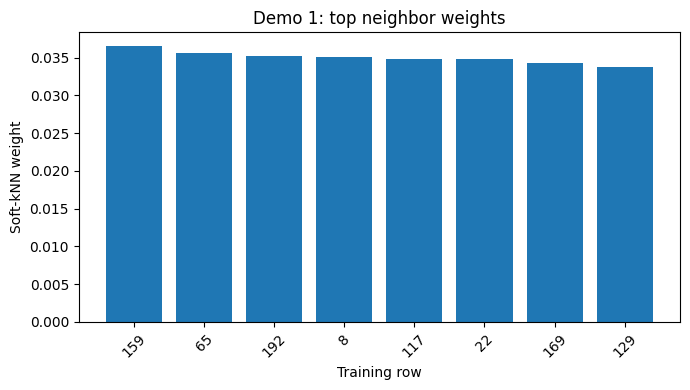

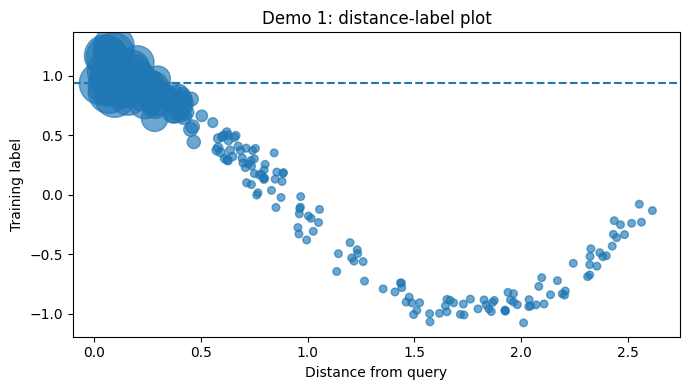

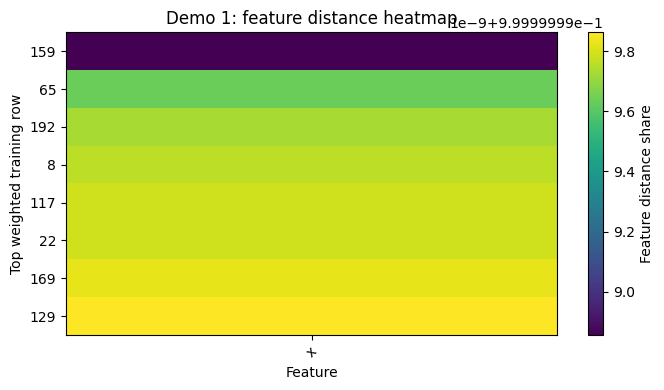

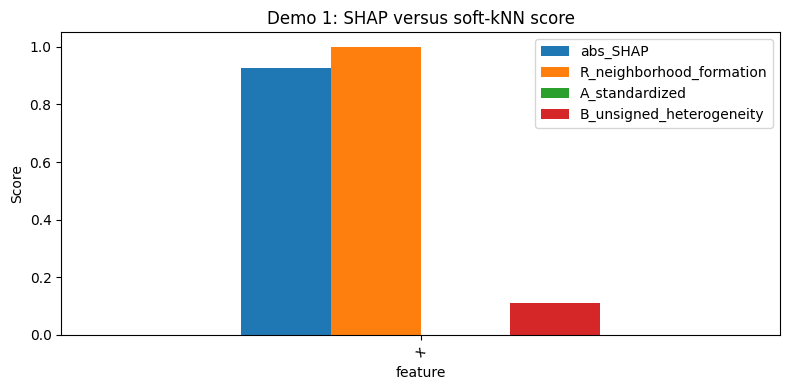

,abs_SHAP,R_neighborhood_formation,A_standardized,B_unsigned_heterogeneity
feature,,,,
x,0.926906,1.0,-4.974198e-11,0.109777


In [4]:
# Pick one query and render explanation panels
q = np.array([0.25])
qz = standardize_apply(q.reshape(1, -1), mu, sd)[0]
diag1 = soft_knn_diagnostics(Xz, y, qz, tau=tau, feature_names=feature_names, top_k=8)
phi0_1, phi1 = exact_interventional_shap(f_demo1, q, x)

print("Prediction:", diag1["prediction"])
print("Baseline phi0:", phi0_1)
print("SHAP phi:", phi1)
print("Diagnostics:", {k: diag1[k] for k in ["neff", "delta_y", "delta_x", "wmax"]})
display(diag1["ledger"])
display(diag1["feature_scores"])

plot_top_neighbor_weights(diag1, "Demo 1: top neighbor weights", top_k=8)
plot_distance_label(diag1, y, "Demo 1: distance-label plot")
plot_feature_heatmap(diag1, "Demo 1: feature distance heatmap", top_k=8)
plot_shap_vs_soft_scores(feature_names, phi1, diag1["feature_scores"], "Demo 1: SHAP versus soft-kNN score")

### Interpretation

In one dimension, the soft-kNN feature-geometry score \(R_1\) is necessarily 1. The key value of the soft-kNN explanation is therefore not feature ranking. It is the evidence layer:

\[
\{(x_i,y_i,w_i,d_i)\}_{i\in \text{TopK}},
\quad
N_{\mathrm{eff}},
\quad
\Delta_y,
\quad
\Delta_x.
\]

This shows whether the prediction comes from local consensus or from a fragile average.

## 3. Demonstration 2: Same prediction, different local evidence

Now we create two regions with nearly the same prediction but very different local label dispersion.

- Region A has local consensus around 0.5.
- Region B has conflicting labels that average to 0.5.

SHAP can look similar because the outer prediction is similar. The soft-kNN explanation separates the two cases using \(\Delta_y\) and the distance-label plot.

In [5]:
# Demonstration 2
np.random.seed(8)

n_region = 80
xA = 0.25 + 0.025 * np.random.randn(n_region, 1)
yA = 0.5 + 0.05 * np.random.randn(n_region)

xB = 0.75 + 0.025 * np.random.randn(n_region, 1)
signs = np.random.choice([-1, 1], size=n_region)
yB = 0.5 + 0.4 * signs + 0.05 * np.random.randn(n_region)

x_fill = np.random.rand(80, 1)
y_fill = 0.5 + 0.25 * np.random.randn(80)

X2 = np.vstack([xA, xB, x_fill])
y2 = np.concatenate([yA, yB, y_fill])

X2z, mu2, sd2 = standardize_train(X2)
tau2 = 0.12
feature_names2 = ["x"]

def f_demo2(X_input_original_scale):
    X_input_z = standardize_apply(np.asarray(X_input_original_scale), mu2, sd2)
    return soft_knn_predict(X2z, y2, X_input_z, tau=tau2)

queries2 = [np.array([0.25]), np.array([0.75])]
rows = []
diags2 = []
phis2 = []
for q in queries2:
    qz = standardize_apply(q.reshape(1, -1), mu2, sd2)[0]
    diag = soft_knn_diagnostics(X2z, y2, qz, tau=tau2, feature_names=feature_names2, top_k=10)
    phi0, phi = exact_interventional_shap(f_demo2, q, X2)
    diags2.append(diag)
    phis2.append(phi)
    rows.append({
        "query_x": q[0],
        "prediction": diag["prediction"],
        "SHAP_x": phi[0],
        "N_eff": diag["neff"],
        "Delta_y": diag["delta_y"],
        "Delta_x": diag["delta_x"],
        "w_max": diag["wmax"]
    })
pd.DataFrame(rows)

,query_x,prediction,SHAP_x,N_eff,Delta_y,Delta_x,w_max
0,0.25,0.503988,-0.006045,75.938966,0.005622,0.007049,0.015867
1,0.75,0.513246,0.003213,82.982785,0.154317,0.006401,0.014431



Region A: local consensus
Prediction: 0.503987850910051
SHAP: [-0.00604499]
Diagnostics: {'neff': np.float64(75.93896571068622), 'delta_y': np.float64(0.005621704052638574), 'delta_x': np.float64(0.007049322416488627), 'wmax': np.float64(0.015866936134662463)}


,rank,row,y,weight,distance,signed_residual,x
0,1,32,0.581615,0.015867,0.002962,0.077627,-0.908059
1,2,34,0.471110,0.015852,0.005962,-0.032878,-0.916983
2,3,18,0.490282,0.015850,0.006221,-0.013706,-0.917242
3,4,43,0.511189,0.015844,0.007158,0.007201,-0.903863
4,5,41,0.557701,0.015836,0.008007,0.053713,-0.903014
5,6,0,0.517826,0.015831,0.008641,0.013838,-0.902380
6,7,60,0.518043,0.015826,0.009112,0.014055,-0.901910
7,8,72,0.487618,0.015812,0.010383,-0.016370,-0.900638


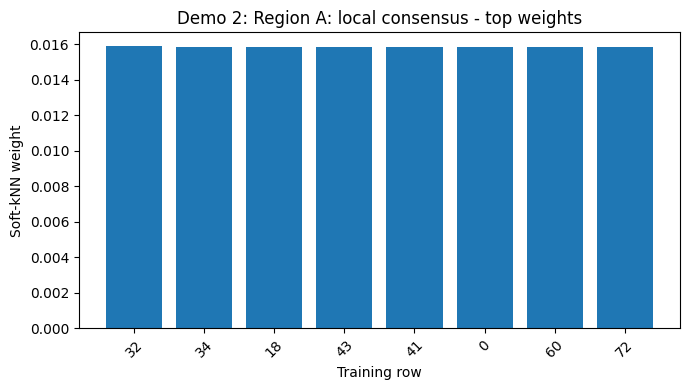

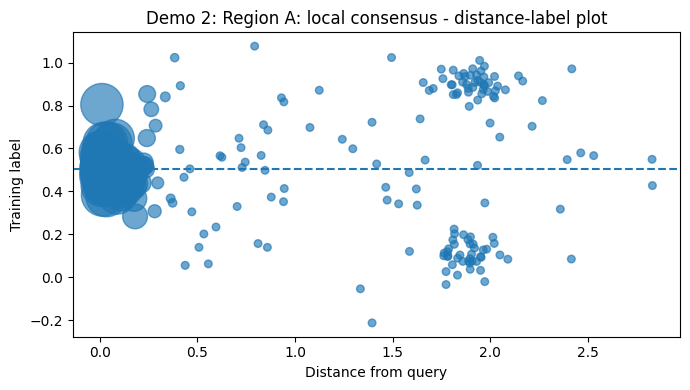


Region B: conflicting evidence
Prediction: 0.5132463144478503
SHAP: [0.00321347]
Diagnostics: {'neff': np.float64(82.98278460840055), 'delta_y': np.float64(0.15431662036225358), 'delta_x': np.float64(0.006401159731597925), 'wmax': np.float64(0.014431022466808245)}


,rank,row,y,weight,distance,signed_residual,x
0,1,109,0.065779,0.014431,0.000912,-0.447468,0.984742
1,2,237,0.086414,0.014431,0.001162,-0.426832,0.984991
2,3,96,0.796070,0.014429,0.002105,0.282823,0.981724
3,4,104,0.154811,0.014429,0.002352,-0.358435,0.986181
4,5,120,0.036786,0.014428,0.002800,-0.476460,0.986630
5,6,167,0.188027,0.014423,0.004196,-0.325220,0.988026
6,7,86,0.940971,0.014422,0.004363,0.427724,0.988192
7,8,147,0.074370,0.014417,0.005297,-0.438876,0.978533


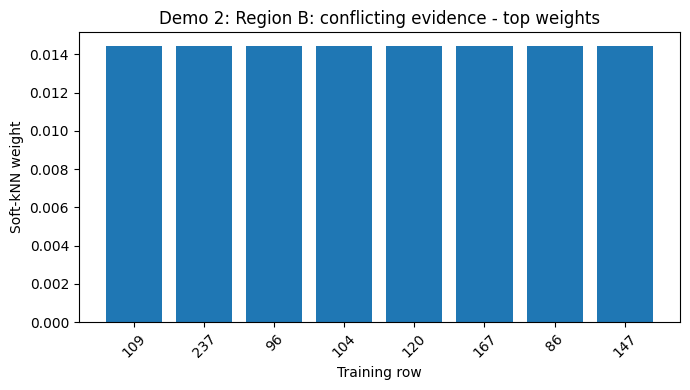

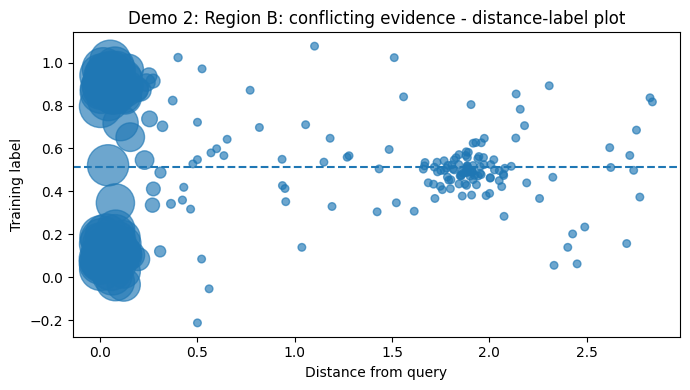

In [6]:
# Render both cases
for idx, label in enumerate(["Region A: local consensus", "Region B: conflicting evidence"]):
    print("\n", "="*80)
    print(label)
    print("Prediction:", diags2[idx]["prediction"])
    print("SHAP:", phis2[idx])
    print("Diagnostics:", {k: diags2[idx][k] for k in ["neff", "delta_y", "delta_x", "wmax"]})
    display(diags2[idx]["ledger"].head(8))
    plot_top_neighbor_weights(diags2[idx], f"Demo 2: {label} - top weights", top_k=8)
    plot_distance_label(diags2[idx], y2, f"Demo 2: {label} - distance-label plot")

### Interpretation

The important comparison is not just the predicted value. It is the local evidence quality.

If two queries have similar \(\hat y(x_0)\) and similar SHAP values, but one has much larger \(\Delta_y\), then one prediction is supported by local consensus while the other is an average over disagreement.

That distinction is central in high-risk applications, and it is not naturally produced by a feature-attribution vector.

## 4. Demonstration 3: Neighbor-switching boundary

This demonstration shows the best one-line mechanism in the paper.

In the ideal two-prototype case:

\[
\frac{d\hat y(t)}{dt}
=
\frac{dw_2(t)}{dt}(y_2-y_1).
\]

The apparent feature effect is entirely mediated by a change in neighbor weights.

In [7]:
# Demonstration 3
np.random.seed(9)
nA = 100
nB = 100
XA = np.random.randn(nA, 2) * 0.15 + np.array([-1.0, 0.0])
XB = np.random.randn(nB, 2) * 0.15 + np.array([1.0, 0.0])
X3 = np.vstack([XA, XB])
y3 = np.concatenate([np.zeros(nA), np.ones(nB)])
cluster = np.array(["left"] * nA + ["right"] * nB)

X3z, mu3, sd3 = standardize_train(X3)
tau3 = 0.55
feature_names3 = ["x1", "x2"]

def f_demo3(X_input_original_scale):
    X_input_z = standardize_apply(np.asarray(X_input_original_scale), mu3, sd3)
    return soft_knn_predict(X3z, y3, X_input_z, tau=tau3)

grid_t = np.linspace(-1.5, 1.5, 61)
curve = []
for t in grid_t:
    q = np.array([t, 0.0])
    qz = standardize_apply(q.reshape(1, -1), mu3, sd3)[0]
    diag = soft_knn_diagnostics(X3z, y3, qz, tau=tau3, feature_names=feature_names3, top_k=10)
    W_right = np.sum(diag["weights"][cluster == "right"])
    phi0, phi = exact_interventional_shap(f_demo3, q, X3)
    curve.append({
        "t": t,
        "prediction": diag["prediction"],
        "right_cluster_mass": W_right,
        "N_eff": diag["neff"],
        "SHAP_x1": phi[0],
        "SHAP_x2": phi[1]
    })
curve_df = pd.DataFrame(curve)
curve_df.head()

,t,prediction,right_cluster_mass,N_eff,SHAP_x1,SHAP_x2
0,-1.50,0.000118,0.000118,58.568067,-0.500018,0.000052
1,-1.45,0.000160,0.000160,59.195759,-0.499975,0.000051
2,-1.40,0.000217,0.000217,59.759332,-0.499917,0.000050
3,-1.35,0.000295,0.000295,60.258638,-0.499838,0.000048
4,-1.30,0.000400,0.000400,60.694074,-0.499731,0.000046


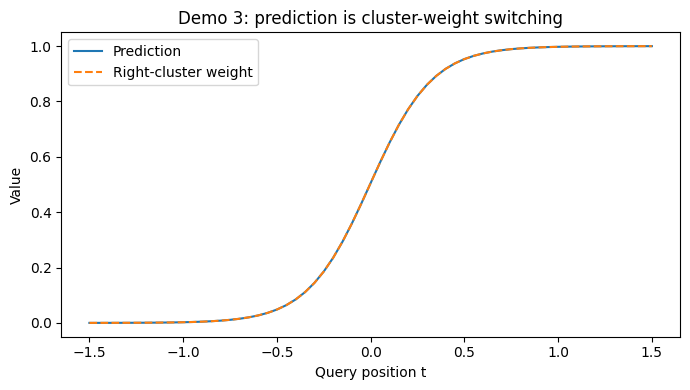

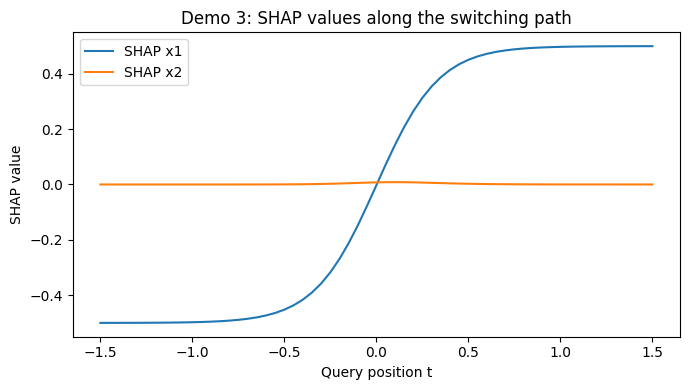

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(curve_df["t"], curve_df["prediction"], label="Prediction")
plt.plot(curve_df["t"], curve_df["right_cluster_mass"], linestyle="--", label="Right-cluster weight")
plt.xlabel("Query position t")
plt.ylabel("Value")
plt.title("Demo 3: prediction is cluster-weight switching")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(curve_df["t"], curve_df["SHAP_x1"], label="SHAP x1")
plt.plot(curve_df["t"], curve_df["SHAP_x2"], label="SHAP x2")
plt.xlabel("Query position t")
plt.ylabel("SHAP value")
plt.title("Demo 3: SHAP values along the switching path")
plt.legend()
plt.tight_layout()
plt.show()

Prediction: 0.5052493857919833
SHAP: {'x1': np.float64(-0.0024980684033366896), 'x2': np.float64(0.0076632687453469794)}
Diagnostics: {'neff': np.float64(107.96687992364012), 'delta_y': np.float64(0.2499724439488069), 'delta_x': np.float64(1.121335340417769), 'wmax': np.float64(0.02156743318209135)}


,rank,row,y,weight,distance,signed_residual,x1,x2
0,1,23,0.0,0.021567,0.708325,-0.505249,-0.699894,-0.184701
1,2,48,0.0,0.018475,0.771585,-0.505249,-0.779832,-0.004106
2,3,169,1.0,0.018350,0.774248,0.494751,0.759127,0.069707
3,4,147,1.0,0.016579,0.812942,0.494751,0.791061,0.115958
4,5,182,1.0,0.015829,0.829979,0.494751,0.806271,0.127274
5,6,134,1.0,0.015813,0.830365,0.494751,0.772206,-0.312308
6,7,7,0.0,0.015704,0.832864,-0.505249,-0.713638,0.413550
7,8,46,0.0,0.015525,0.837031,-0.505249,-0.844335,0.018032
8,9,71,0.0,0.014621,0.858442,-0.505249,-0.839124,0.187501
9,10,183,1.0,0.014402,0.863744,0.494751,0.809813,0.245951


,feature,R_neighborhood_formation,A_signed_outcome_contrast,A_standardized,B_unsigned_heterogeneity
0,x1,0.836449,0.001657,0.003315,0.418161
1,x2,0.163551,-0.001657,-0.003315,0.081784


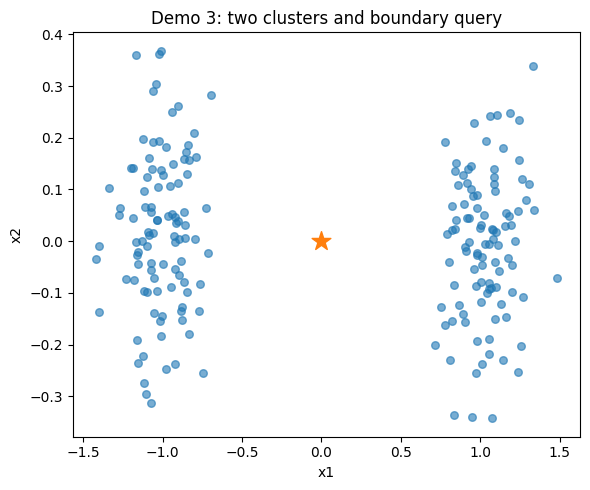

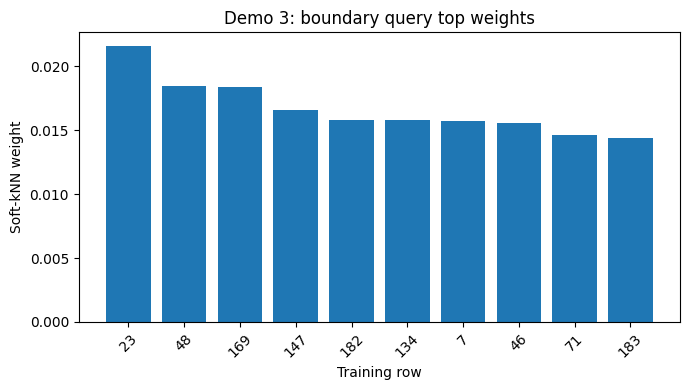

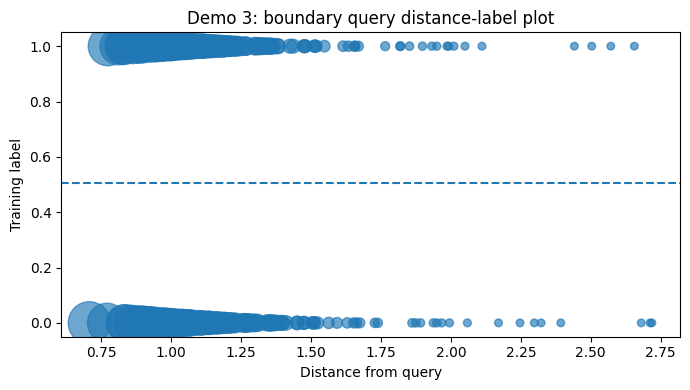

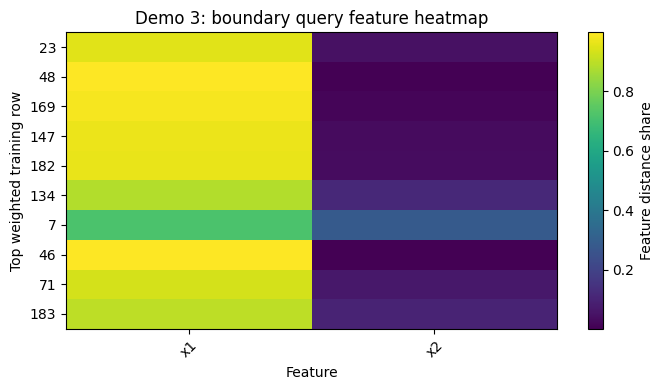

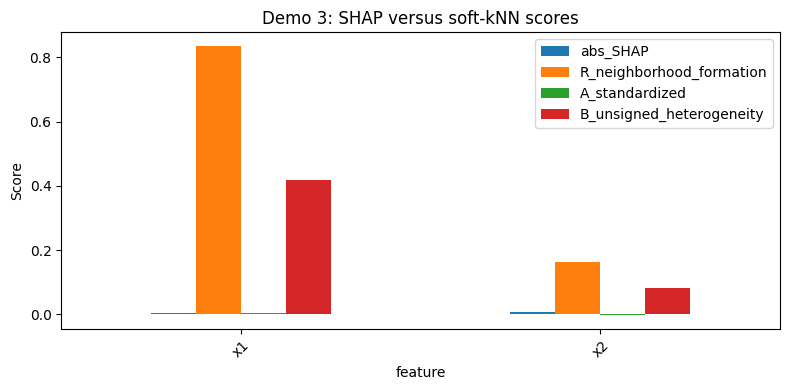

,feature,SHAP,abs_SHAP,R_neighborhood_formation,A_standardized,B_unsigned_heterogeneity
0,x1,-0.002498,0.002498,0.836449,0.003315,0.418161
1,x2,0.007663,0.007663,0.163551,-0.003315,0.081784


,criterion,value
0,rho_geom,-1.0
1,rho_contrast,-1.0
2,rho_hetero,-1.0


In [9]:
# Query near the switching boundary
q = np.array([0.0, 0.0])
qz = standardize_apply(q.reshape(1, -1), mu3, sd3)[0]
diag3 = soft_knn_diagnostics(X3z, y3, qz, tau=tau3, feature_names=feature_names3, top_k=10)
phi0_3, phi3 = exact_interventional_shap(f_demo3, q, X3)

print("Prediction:", diag3["prediction"])
print("SHAP:", dict(zip(feature_names3, phi3)))
print("Diagnostics:", {k: diag3[k] for k in ["neff", "delta_y", "delta_x", "wmax"]})
display(diag3["ledger"].head(10))
display(diag3["feature_scores"])

plt.figure(figsize=(6, 5))
plt.scatter(X3[:, 0], X3[:, 1], s=30, alpha=0.6)
plt.scatter([q[0]], [q[1]], marker="*", s=200)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Demo 3: two clusters and boundary query")
plt.tight_layout()
plt.show()

plot_top_neighbor_weights(diag3, "Demo 3: boundary query top weights", top_k=10)
plot_distance_label(diag3, y3, "Demo 3: boundary query distance-label plot")
plot_feature_heatmap(diag3, "Demo 3: boundary query feature heatmap", top_k=10)
plot_shap_vs_soft_scores(feature_names3, phi3, diag3["feature_scores"], "Demo 3: SHAP versus soft-kNN scores")
comparison_df3, summary_df3 = comparison_table(feature_names3, phi3, diag3["feature_scores"])
display(comparison_df3)
display(summary_df3)

### Interpretation

SHAP correctly identifies \(x_1\) as important, but the mechanism is not a structural linear effect. The mechanism is row-weight transfer from the left cluster to the right cluster.

The soft-kNN explanation makes the switching visible through:

- right-cluster mass,
- top-neighbor identities,
- the distance-label plot,
- \(N_{\mathrm{eff}}\) and \(\Delta_y\).

## 5. Demonstration 4: Density-mediated feature effect

This demonstration separates structural response effect from neighborhood-selection effect.

The response is generated from

\[
y = x_1 + 0.10\epsilon.
\]

The second feature \(x_2\) does not directly determine the response. But it affects the data manifold and therefore can change which rows are retrieved by soft kNN.

This is a common situation in tabular data: a feature can matter because it changes neighborhood composition, not because it has a direct response effect.

In [10]:
# Demonstration 4
np.random.seed(10)
n4 = 500
x1 = np.random.uniform(-1, 1, size=n4)
x2 = 2 * (x1 > 0).astype(float) + 0.20 * np.random.randn(n4)
X4 = np.column_stack([x1, x2])
y4 = x1 + 0.10 * np.random.randn(n4)

X4z, mu4, sd4 = standardize_train(X4)
tau4 = 0.35
feature_names4 = ["x1_structural", "x2_density"]

def f_demo4(X_input_original_scale):
    X_input_z = standardize_apply(np.asarray(X_input_original_scale), mu4, sd4)
    return soft_knn_predict(X4z, y4, X_input_z, tau=tau4)

queries4 = {
    "on_manifold": np.array([0.30, 2.0]),
    "off_manifold": np.array([0.30, 0.0])
}

rows = []
diags4 = {}
phis4 = {}
for name, q in queries4.items():
    qz = standardize_apply(q.reshape(1, -1), mu4, sd4)[0]
    diag = soft_knn_diagnostics(X4z, y4, qz, tau=tau4, feature_names=feature_names4, top_k=10)
    phi0, phi = exact_interventional_shap(f_demo4, q, X4)
    diags4[name] = diag
    phis4[name] = phi
    rows.append({
        "query": name,
        "x1": q[0],
        "x2": q[1],
        "prediction": diag["prediction"],
        "SHAP_x1": phi[0],
        "SHAP_x2": phi[1],
        "N_eff": diag["neff"],
        "Delta_y": diag["delta_y"],
        "Delta_x": diag["delta_x"],
        "w_max": diag["wmax"]
    })
pd.DataFrame(rows)

,query,x1,x2,prediction,SHAP_x1,SHAP_x2,N_eff,Delta_y,Delta_x,w_max
0,on_manifold,0.3,2.0,0.311816,0.104605,0.223741,167.191613,0.044477,0.135299,0.009255
1,off_manifold,0.3,0.0,-0.085352,0.159501,-0.228323,38.676024,0.016602,0.534355,0.054174


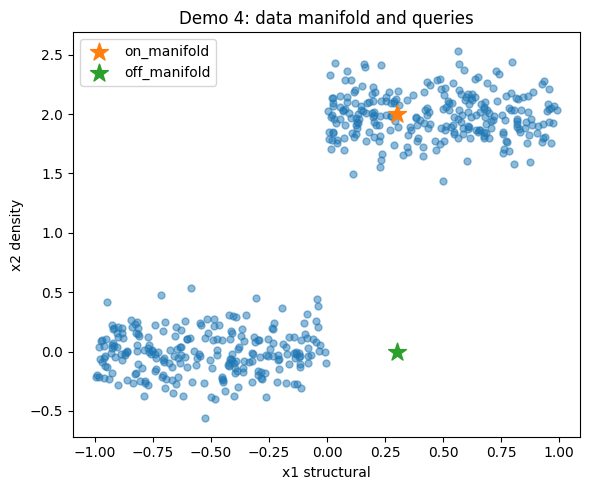


on_manifold
Prediction: 0.3118160423464159
SHAP: {'x1_structural': np.float64(0.10460523122089871), 'x2_density': np.float64(0.22374065505269802)}
Diagnostics: {'neff': np.float64(167.1916129520499), 'delta_y': np.float64(0.044476919584915245), 'delta_x': np.float64(0.13529922525861857), 'wmax': np.float64(0.009255039466029805)}


,rank,row,y,weight,distance,signed_residual,x1_structural,x2_density
0,1,28,0.359579,0.009255,0.012033,0.047763,0.550525,0.972043
1,2,278,0.273683,0.009189,0.043428,-0.038133,0.507458,0.947902
2,3,447,0.289518,0.009173,0.048108,-0.022298,0.502793,0.947196
3,4,454,0.190082,0.009133,0.058379,-0.121734,0.533425,0.903866
4,5,196,0.392093,0.009040,0.076918,0.080277,0.569091,1.034375
5,6,341,0.335149,0.008999,0.083767,0.023333,0.466032,0.949613
6,7,209,0.441442,0.008918,0.096074,0.129626,0.529376,1.054109
7,8,429,0.172911,0.008903,0.098251,-0.138905,0.507060,1.048872
8,9,408,0.196805,0.008823,0.108923,-0.115011,0.556090,0.851389
9,10,128,0.056827,0.008797,0.112126,-0.254989,0.531973,1.070894


,feature,R_neighborhood_formation,A_signed_outcome_contrast,A_standardized,B_unsigned_heterogeneity
0,x1_structural,0.686251,0.010129,0.048027,0.133718
1,x2_density,0.313749,-0.010129,-0.048027,0.039800


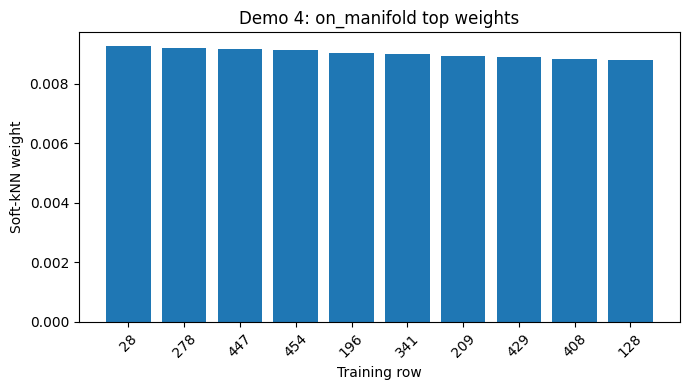

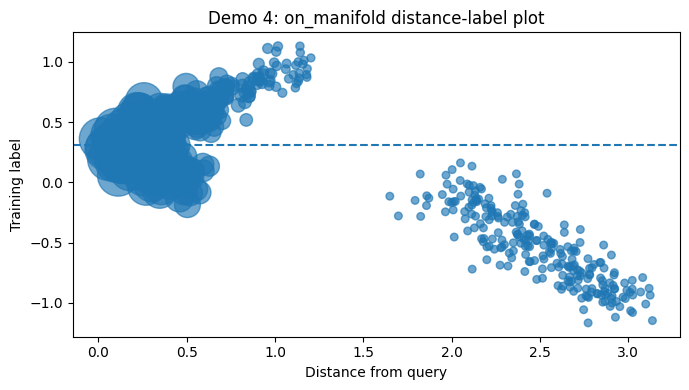

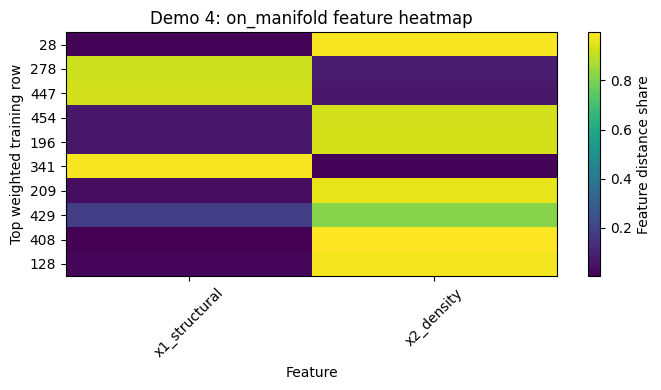

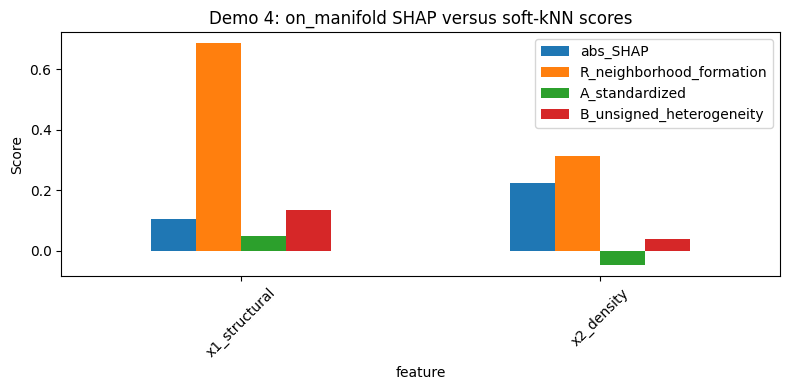

,feature,SHAP,abs_SHAP,R_neighborhood_formation,A_standardized,B_unsigned_heterogeneity
0,x1_structural,0.104605,0.104605,0.686251,0.048027,0.133718
1,x2_density,0.223741,0.223741,0.313749,-0.048027,0.039800


,criterion,value
0,rho_geom,-1.0
1,rho_contrast,1.0
2,rho_hetero,-1.0



off_manifold
Prediction: -0.08535199006330035
SHAP: {'x1_structural': np.float64(0.15950082013211553), 'x2_density': np.float64(-0.22832296626823517)}
Diagnostics: {'neff': np.float64(38.6760238107571), 'delta_y': np.float64(0.016601611476582498), 'delta_x': np.float64(0.534355251442222), 'wmax': np.float64(0.05417412690693245)}


,rank,row,y,weight,distance,signed_residual,x1_structural,x2_density
0,1,4,-0.106366,0.054174,0.536453,-0.021014,0.021380,-1.104465
1,2,95,0.015296,0.053368,0.539864,0.100648,0.009331,-1.015942
2,3,180,0.105379,0.044329,0.580446,0.190731,-0.029086,-0.957581
3,4,307,0.161048,0.043374,0.585028,0.246400,-0.035876,-1.004638
4,5,372,-0.160535,0.038615,0.608878,-0.075183,-0.054643,-0.929686
5,6,462,-0.111370,0.035687,0.624538,-0.026018,-0.040696,-0.803008
6,7,124,0.059534,0.033599,0.636254,0.144886,-0.078679,-0.905039
7,8,103,-0.023895,0.031795,0.646792,0.061457,-0.096985,-1.037643
8,9,90,0.068643,0.029814,0.658867,0.153995,-0.060052,-0.757311
9,10,262,0.133975,0.028453,0.667496,0.219327,-0.117213,-1.047325


,feature,R_neighborhood_formation,A_signed_outcome_contrast,A_standardized,B_unsigned_heterogeneity
0,x1_structural,0.956057,0.001512,0.011735,0.098951
1,x2_density,0.043943,-0.001512,-0.011735,0.004273


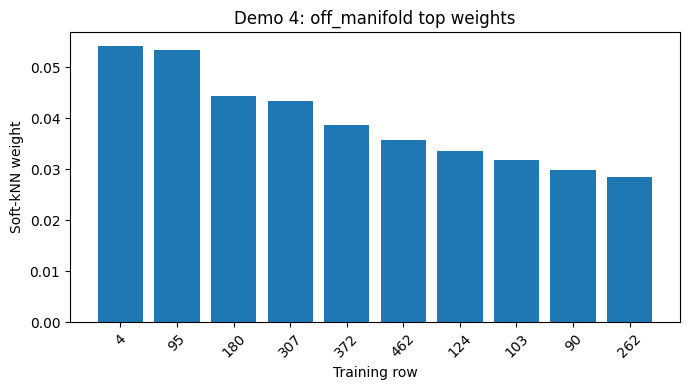

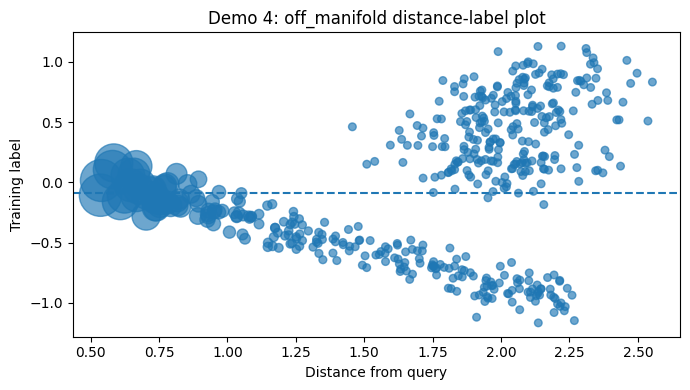

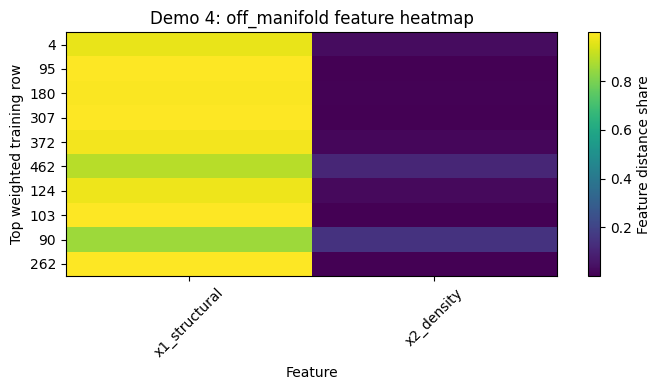

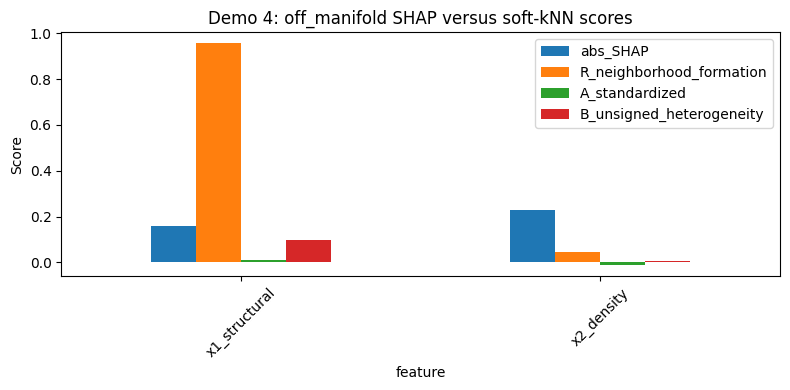

,feature,SHAP,abs_SHAP,R_neighborhood_formation,A_standardized,B_unsigned_heterogeneity
0,x1_structural,0.159501,0.159501,0.956057,0.011735,0.098951
1,x2_density,-0.228323,0.228323,0.043943,-0.011735,0.004273


,criterion,value
0,rho_geom,-1.0
1,rho_contrast,1.0
2,rho_hetero,-1.0


In [11]:
plt.figure(figsize=(6, 5))
plt.scatter(X4[:, 0], X4[:, 1], s=25, alpha=0.5)
for name, q in queries4.items():
    plt.scatter([q[0]], [q[1]], marker="*", s=180, label=name)
plt.xlabel("x1 structural")
plt.ylabel("x2 density")
plt.title("Demo 4: data manifold and queries")
plt.legend()
plt.tight_layout()
plt.show()

for name in queries4:
    print("\n", "="*80)
    print(name)
    print("Prediction:", diags4[name]["prediction"])
    print("SHAP:", dict(zip(feature_names4, phis4[name])))
    print("Diagnostics:", {k: diags4[name][k] for k in ["neff", "delta_y", "delta_x", "wmax"]})
    display(diags4[name]["ledger"].head(10))
    display(diags4[name]["feature_scores"])
    plot_top_neighbor_weights(diags4[name], f"Demo 4: {name} top weights", top_k=10)
    plot_distance_label(diags4[name], y4, f"Demo 4: {name} distance-label plot")
    plot_feature_heatmap(diags4[name], f"Demo 4: {name} feature heatmap", top_k=10)
    plot_shap_vs_soft_scores(feature_names4, phis4[name], diags4[name]["feature_scores"], f"Demo 4: {name} SHAP versus soft-kNN scores")
    comparison_df, summary_df = comparison_table(feature_names4, phis4[name], diags4[name]["feature_scores"])
    display(comparison_df)
    display(summary_df)

### Interpretation

If SHAP assigns value to \(x_2\), the soft-kNN explanation helps diagnose why.

- High \(R_{x_2}\): \(x_2\) forms the local neighborhood.
- High \(A^{\mathrm{std}}_{x_2}\): \(x_2\)-based neighborhood differences are signed with respect to the prediction.
- High \(B_{x_2}\): \(x_2\) is associated with local label heterogeneity.
- High \(\Delta_x\): the query may be off the training manifold.

This is a more precise interpretation than simply saying “\(x_2\) contributes to the prediction.”

## 6. Compact report for a single query

This helper function prints a compact tutorial report. Use it on your own soft-kNN examples.

In [12]:
def soft_knn_report(X_train_original, y_train, x0_original, tau, feature_names):
    Xz, mu, sd = standardize_train(X_train_original)
    x0z = standardize_apply(np.asarray(x0_original).reshape(1, -1), mu, sd)[0]

    def f_original(X_input_original_scale):
        X_input_z = standardize_apply(np.asarray(X_input_original_scale), mu, sd)
        return soft_knn_predict(Xz, y_train, X_input_z, tau=tau)

    diag = soft_knn_diagnostics(Xz, y_train, x0z, tau=tau, feature_names=feature_names, top_k=10)
    phi0, phi = exact_interventional_shap(f_original, x0_original, X_train_original)

    print("Prediction:", diag["prediction"])
    print("SHAP baseline:", phi0)
    print("Diagnostics:")
    display(pd.DataFrame([{
        "N_eff": diag["neff"],
        "entropy": diag["entropy"],
        "Delta_y": diag["delta_y"],
        "Delta_x": diag["delta_x"],
        "w_max": diag["wmax"]
    }]))

    print("Top neighbor ledger:")
    display(diag["ledger"])

    print("Feature comparison:")
    comparison_df, summary_df = comparison_table(feature_names, phi, diag["feature_scores"])
    display(comparison_df)
    display(summary_df)

    plot_top_neighbor_weights(diag, "Top neighbor weights", top_k=10)
    plot_distance_label(diag, y_train, "Distance-label plot")
    plot_feature_heatmap(diag, "Feature distance heatmap", top_k=10)
    plot_shap_vs_soft_scores(feature_names, phi, diag["feature_scores"], "SHAP versus soft-kNN scores")

    return diag, phi

# Example usage:
# diag, phi = soft_knn_report(X4, y4, np.array([0.30, 2.0]), tau4, feature_names4)

## 7. Summary

The paper’s main message is visible in these demonstrations:

\[
\text{SHAP explains } x_0 \mapsto \hat y(x_0),
\qquad
\text{soft kNN explains } x_0 \mapsto w(x_0) \mapsto \hat y(x_0).
\]

For explicit soft kNN, the weights \(w_i(x_0)\) are not merely a heuristic explanation. They are the exact local derivatives:

\[
\frac{\partial \hat y(x_0)}{\partial y_i}=w_i(x_0).
\]

So the faithful local explanation should include the weighted neighborhood, not only feature attributions.

Practical rule:

- Use SHAP for a compact feature-level outer summary.
- Use soft-kNN explanation for the actual local evidence structure.
- Treat disagreement between the two as diagnostic, not as a failure.